                              nombre      sector  facturacion  coste_ventas  \
0                  Ferretería García  Ferretería       320000        210000   
1                      Bar El Rincón  Hostelería       180000         95000   
2                     Peluquería Ana  Peluquería        95000         38000   
3                    Tienda Moda Sol        Moda       210000        140000   
4                     Gestoría Pérez    Gestoría       140000         45000   
5            Clínica Dental Martínez       Salud       280000         84000   
6               Academia Idiomas Sol   Educación       160000         48000   
7              Clínica Dental García       Salud       295000        118000   
8  Academia de Idiomas English House   Educación       155000         77500   

   empleados  deuda  activo_total  año_fundacion  
0          5  45000        180000           2008  
1          4  12000         85000           2015  
2          2   8000         40000           2019  
3    

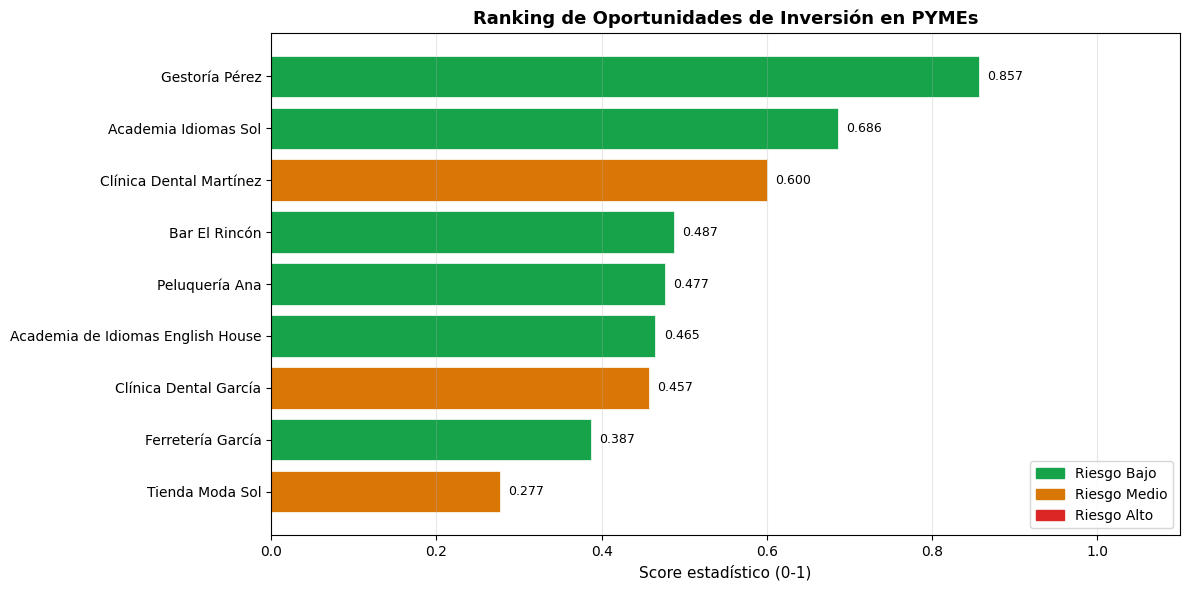

Gráfico guardado como grafico_ranking_pymes.png


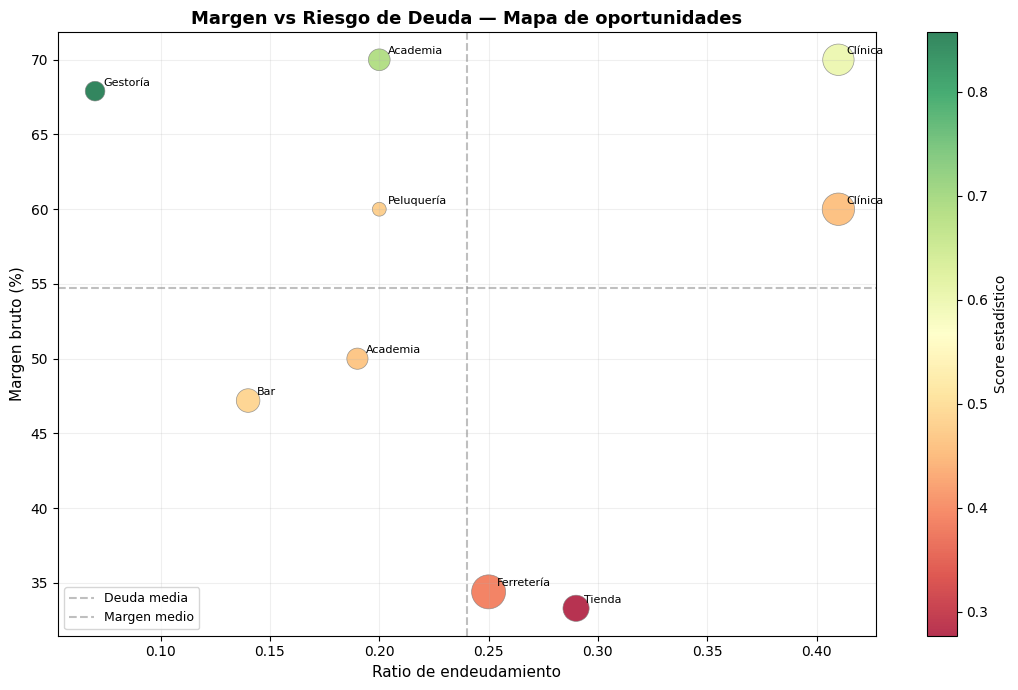

Gráfico guardado como scatter_margen_deuda.png


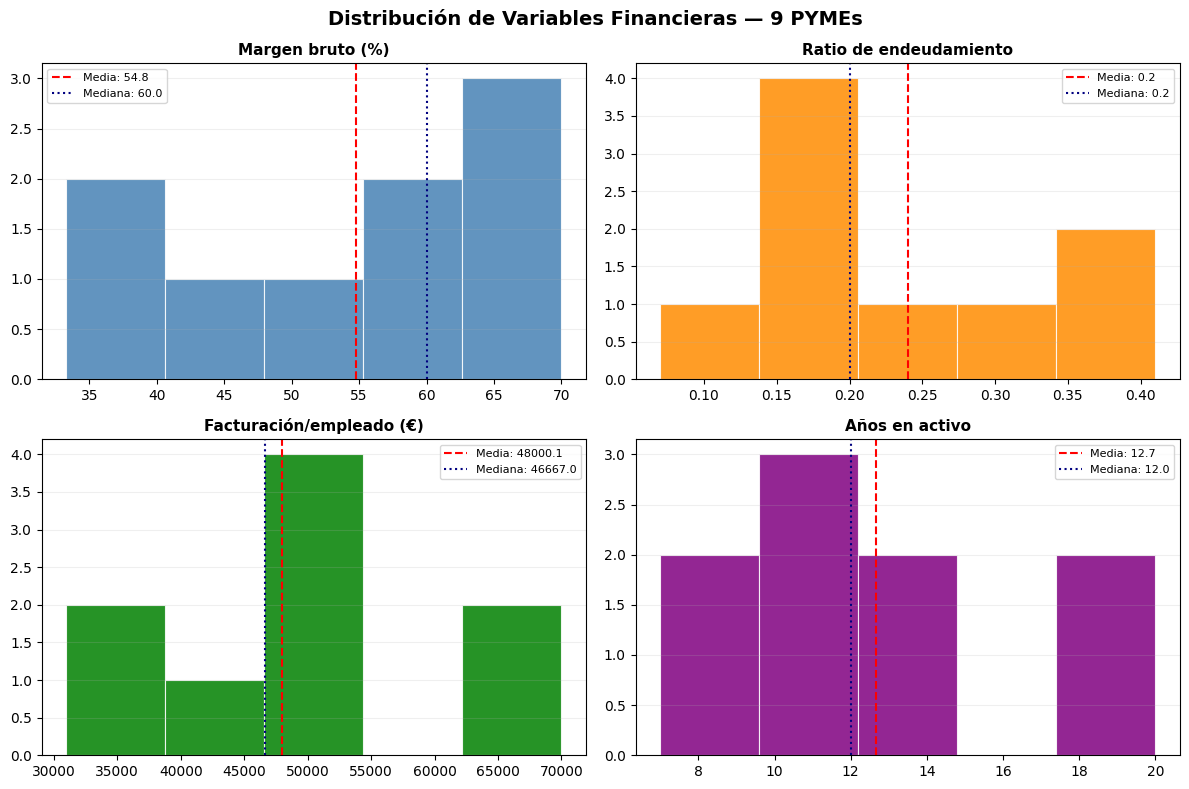

✅ Histogramas guardados como histogramas_pymes.png


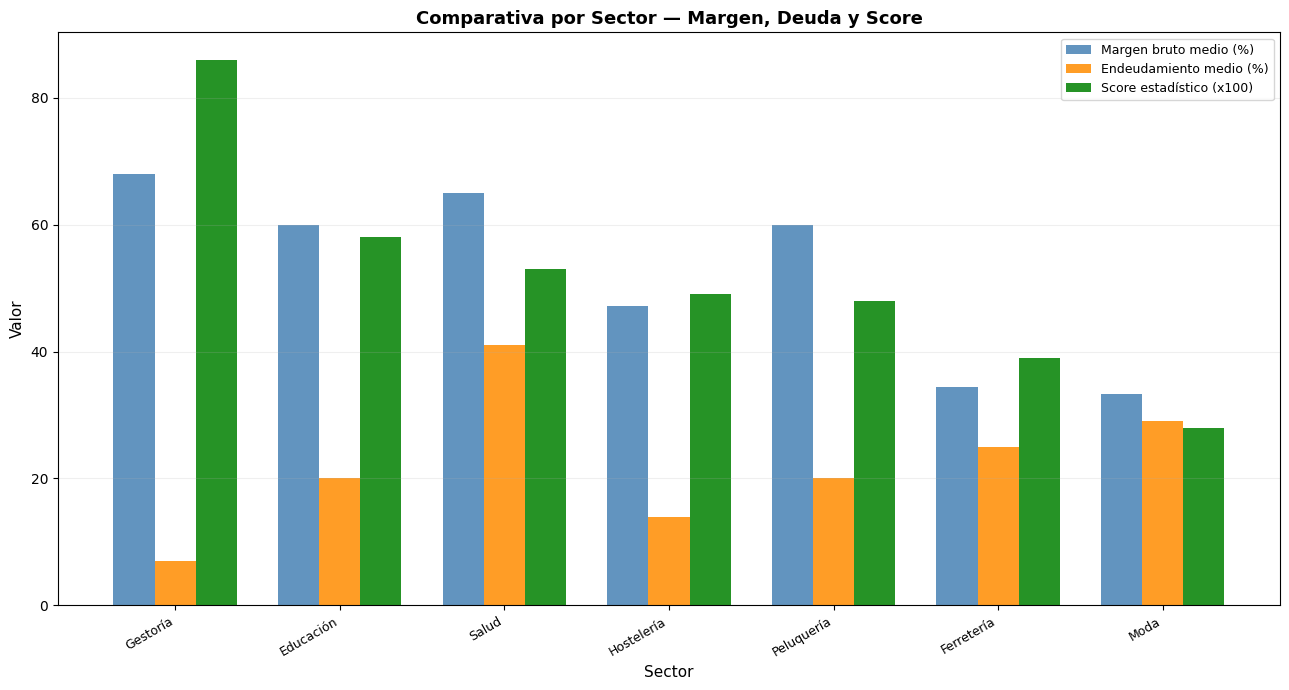

✅ Gráfico guardado como comparativa_sectorial.png


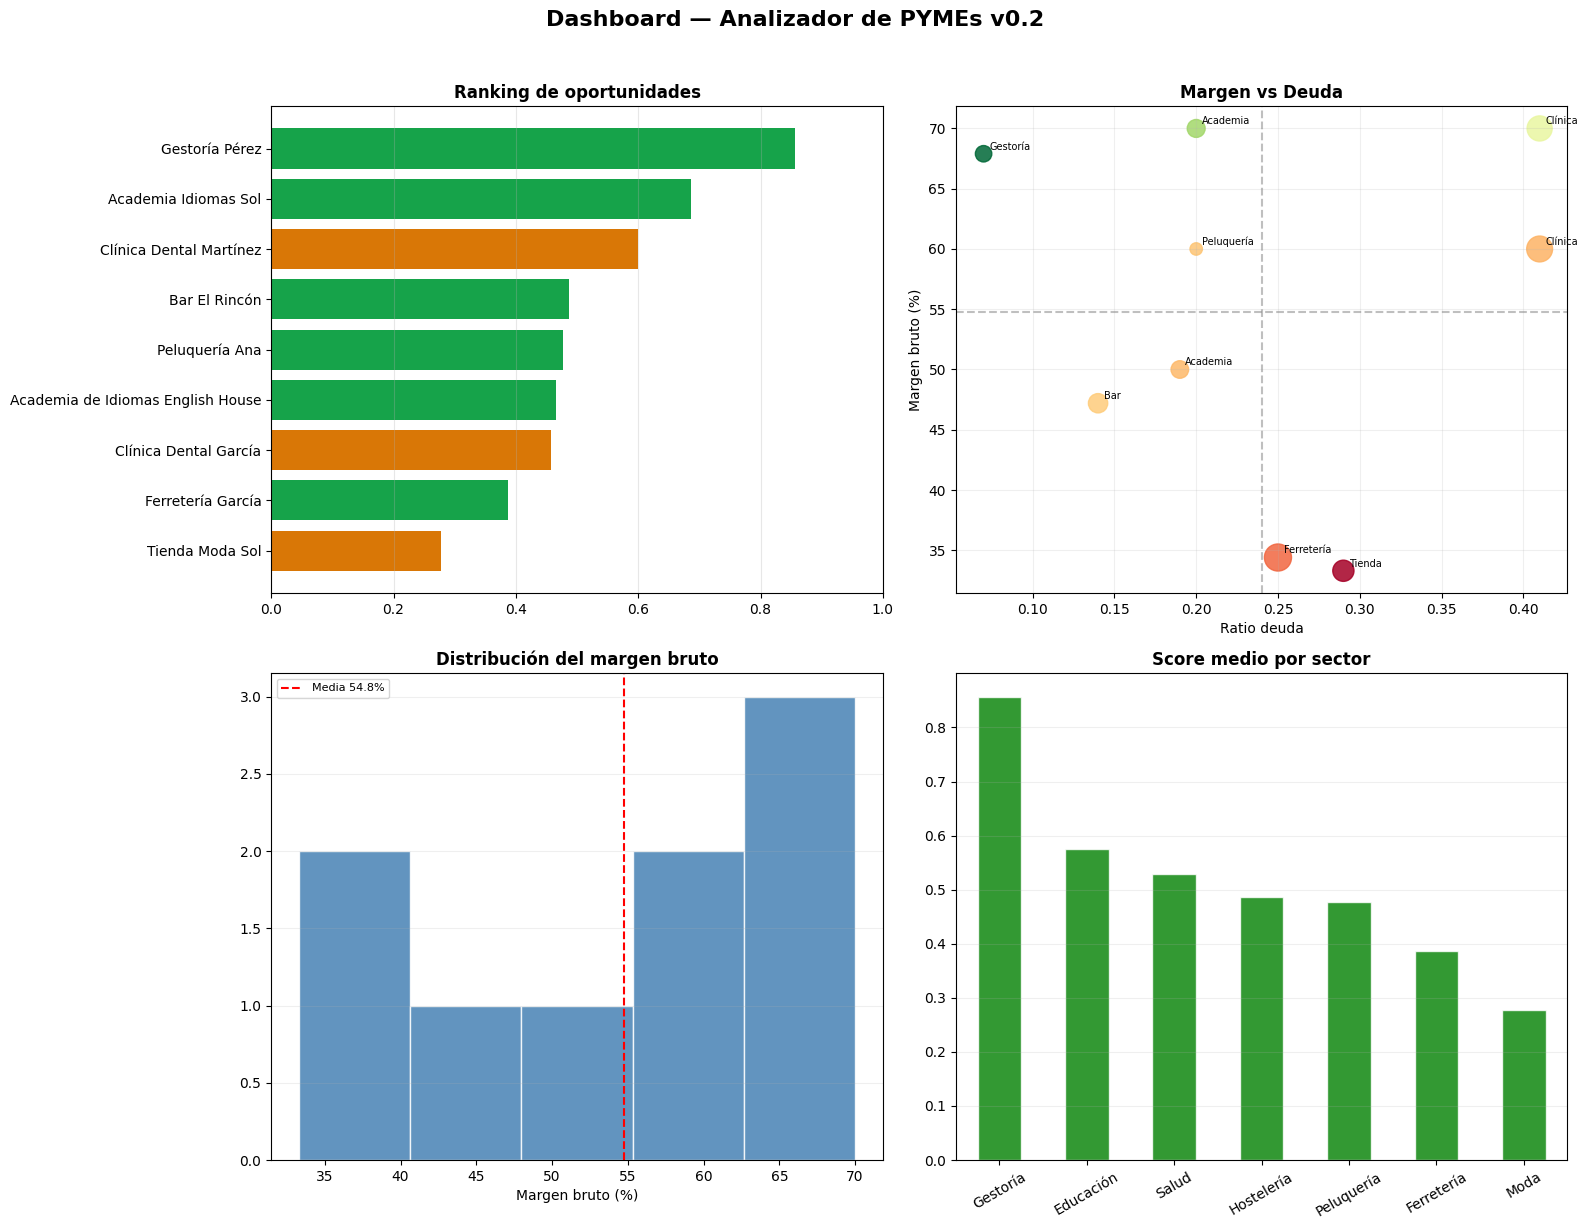

✅ Dashboard guardado como dashboard_pymes_v02.png


In [3]:
import pandas as pd

## 1. Datos de entrada
# --- BLOQUE 1: DATAFRAME DE 7 EMPRESAS---
datos = {
    'nombre': ['Ferretería García','Bar El Rincón','Peluquería Ana','Tienda Moda Sol','Gestoría Pérez', 'Clínica Dental Martínez','Academia Idiomas Sol', 'Clínica Dental García','Academia de Idiomas English House'],
    'sector': ['Ferretería','Hostelería','Peluquería','Moda','Gestoría','Salud','Educación','Salud','Educación'],
    'facturacion': [320000, 180000, 95000, 210000, 140000, 280000,160000,295000,155000],
    'coste_ventas': [210000, 95000, 38000, 140000, 45000,84000,48000,118000,77500],
    'empleados': [5, 4, 2, 3, 3,6,5,6,5],
    'deuda': [45000, 12000, 8000, 35000, 5000,90000,15000,95000,14000],
    'activo_total': [180000, 85000, 40000, 120000, 70000,220000,75000,230000,72000],
    'año_fundacion': [2008, 2015, 2019, 2012, 2006,2014,2016,2013,2017]
}

df = pd.DataFrame(datos)
print(df)
print('\nNúmero de empresas analizadas:', len(df))

## 2. Cálculo de ratios
# --- BLOQUE 2: CÁLCULO DE RATIOS FINANCIEROS ---
# pandas calcula el ratio para TODAS las empresas a la vez con una sola línea
# es lo mismo que hacías con el diccionario pero para las 5 empresas simultáneamente

# Margen bruto en porcentaje
df['margen_bruto_pct'] = ((df['facturacion'] - df['coste_ventas']) / df['facturacion'] * 100).round(1)

# Ratio de endeudamiento (deuda / lo que tiene la empresa)
df['ratio_endeudamiento'] = (df['deuda'] / df['activo_total']).round(2)

# Facturación por empleado — eficiencia del negocio
df['fact_por_empleado'] = (df['facturacion'] / df['empleados']).round(0)

# Años que lleva abierta la empresa
df['años_activo'] = 2026 - df['año_fundacion']

# Ver la tabla con los nuevos ratios calculados
print(df[['nombre', 'margen_bruto_pct', 'ratio_endeudamiento', 'fact_por_empleado', 'años_activo']])

# --- BLOQUE 3: FILTROS DE INVERSIÓN ---
# Usamos los ratios calculados arriba para filtrar empresas
# df[condición] devuelve solo las filas donde la condición es True

# Empresas con bajo riesgo de deuda (menos del 30%)
bajo_riesgo = df[df['ratio_endeudamiento'] < 0.3]
print('Empresas con bajo endeudamiento:')
print(bajo_riesgo[['nombre', 'ratio_endeudamiento']])

# Empresas con buen margen Y bajo riesgo a la vez
# & significa que las dos condiciones tienen que cumplirse
candidatas = df[(df['margen_bruto_pct'] > 25) & (df['ratio_endeudamiento'] < 0.4)]
print('\nMejores candidatas para inversión:')
print(candidatas[['nombre', 'margen_bruto_pct', 'ratio_endeudamiento']])

# Ordenar todas las empresas por margen de mayor a menor
# ascending=False significa de mayor a menor
ranking = df.sort_values('margen_bruto_pct', ascending=False)
print('\nRanking por margen bruto:')
print(ranking[['nombre', 'margen_bruto_pct']])

# Empresas que están por encima de la media del grupo
media_margen = df['margen_bruto_pct'].mean()
sobre_media = df[df['margen_bruto_pct'] > media_margen]
print('\nEmpresas sobre la media del grupo:')
print(sobre_media['nombre'].tolist())

# --- BLOQUE 4: SCORING AUTOMÁTICO CON pd.cut() ---
# Versión mejorada del scoring de la Semana 1 — calcula para todas las empresas a la vez

# Scoring de endeudamiento
bins_deuda = [0, 0.25, 0.5, float('inf')]
labels_deuda = ['Bajo', 'Medio', 'Alto']
df['riesgo_deuda'] = pd.cut(df['ratio_endeudamiento'], bins=bins_deuda, labels=labels_deuda)

# Scoring de margen
bins_margen = [float('-inf'), 15, 30, float('inf')]
labels_margen = ['Bajo', 'Medio', 'Alto']
df['calidad_margen'] = pd.cut(df['margen_bruto_pct'], bins=bins_margen, labels=labels_margen)

# Puntuación numérica combinada
# Margen alto = 3 puntos, medio = 2, bajo = 1
# Deuda baja = 3 puntos, media = 2, alta = 1
# Más de 7 años activa = 2 puntos, menos = 1
mapa_margen = {'Bajo': 1, 'Medio': 2, 'Alto': 3}
mapa_deuda  = {'Bajo': 3, 'Medio': 2, 'Alto': 1}

df['puntos_margen']     = df['calidad_margen'].map(mapa_margen).astype(int)
df['puntos_deuda']      = df['riesgo_deuda'].map(mapa_deuda).astype(int)
df['puntos_antiguedad'] = df['años_activo'].apply(lambda x: 2 if x >= 7 else 1)
df['puntuacion_total']  = df['puntos_margen'] + df['puntos_deuda'] + df['puntos_antiguedad']

print(df[['nombre', 'calidad_margen', 'riesgo_deuda', 'años_activo', 'puntuacion_total']])

# --- BLOQUE 5: RANKING DE OPORTUNIDADES ---
# Ordenar todas las empresas por puntuación total de mayor a menor
# reset_index(drop=True) reinicia el índice desde 0 tras ordenar
ranking = df.sort_values('puntuacion_total', ascending=False).reset_index(drop=True)

# Empezar el índice en 1 en lugar de 0 — más legible como ranking
ranking.index = ranking.index + 1

# Columnas que aparecen en el ranking final
cols_ranking = ['nombre', 'sector', 'facturacion', 'margen_bruto_pct',
                'ratio_endeudamiento', 'años_activo', 'puntuacion_total',
                'calidad_margen', 'riesgo_deuda']

print('=' * 55)
print('RANKING DE OPORTUNIDADES DE INVERSIÓN EN PYMEs')
print('=' * 55)
print(ranking[cols_ranking].to_string())
print('\nMejor oportunidad:', ranking.iloc[0]['nombre'])
print('Mayor riesgo:     ', ranking.iloc[-1]['nombre'])


## 3. Estadística Descriptiva
# --- BLOQUE 6: RESUMEN ESTADÍSTICO Y AGRUPACIÓN ---

# describe() da un resumen estadístico completo de todas las columnas numéricas
# muestra mínimo, máximo, media, mediana y desviación estándar de golpe
print('=== RESUMEN ESTADÍSTICO ===')
print(df[['margen_bruto_pct', 'ratio_endeudamiento', 'fact_por_empleado']].describe())

# Media de cada ratio para todo el conjunto
# sirve para saber si una empresa está por encima o por debajo de la media del grupo
print('\n=== MEDIAS DEL GRUPO ===')
print('Margen bruto medio:', df['margen_bruto_pct'].mean().round(1), '%')
print('Endeudamiento medio:', df['ratio_endeudamiento'].mean().round(2))
print('Facturación por empleado media:', df['fact_por_empleado'].mean().round(0), '€')

# Qué empresa tiene el mejor y peor margen
# idxmax() devuelve el índice de la fila con el valor más alto
print('\n=== DESTACADOS ===')
print('Mejor margen:', df.loc[df['margen_bruto_pct'].idxmax(), 'nombre'])
print('Peor margen:', df.loc[df['margen_bruto_pct'].idxmin(), 'nombre'])
print('Menor riesgo de deuda:', df.loc[df['ratio_endeudamiento'].idxmin(), 'nombre'])

# groupby agrupa las filas por sector y calcula la media de cada grupo
# útil para comparar sectores entre sí — la base del análisis sectorial
print('\n=== MEDIAS POR SECTOR ===')
por_sector = df.groupby('sector')[['margen_bruto_pct', 'ratio_endeudamiento']].mean().round(2)
print(por_sector)
print('\nSectores ordenados por margen (mejor a peor):')
print(por_sector.sort_values('margen_bruto_pct', ascending=False))


# --- BLOQUE 7: RESUMEN DEL ANÁLISIS ---
# Resumen ejecutivo del notebook — lo que le mostrarías a un inversor
# en la primera página de un informe antes de que lea la tabla completa

print('=== ANALIZADOR DE PYMEs v0.1 — RESUMEN ===')

# Total de empresas en el DataFrame
print(f'Empresas analizadas: {len(df)}')

# Número de sectores distintos — nunique() cuenta valores únicos
print(f'Sectores cubiertos: {df["sector"].nunique()}')

# Mejor empresa — primera fila del ranking (mayor puntuación)
print(f'Mejor oportunidad: {ranking.iloc[0]["nombre"]} ({ranking.iloc[0]["puntuacion_total"]} puntos)')

# Peor empresa — última fila del ranking (menor puntuación)
print(f'Mayor riesgo: {ranking.iloc[-1]["nombre"]} ({ranking.iloc[-1]["puntuacion_total"]} puntos)')

# Margen bruto medio del conjunto
print(f'Margen bruto medio del grupo: {df["margen_bruto_pct"].mean().round(1)}%')

# Sector con mejor margen medio
print(f'Sector más rentable: {df.groupby("sector")["margen_bruto_pct"].mean().idxmax()}')


# --- BLOQUE 8: EXPORTACIÓN A EXCEL ---
!pip install openpyxl -q

import openpyxl

nombre_archivo = 'ranking_pymes_v01.xlsx'

with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:

    # Hoja 1: Ranking completo ordenado por puntuación
    ranking[cols_ranking].to_excel(writer, sheet_name='Ranking', index=True)

    # Hoja 2: Datos originales con todos los ratios calculados
    df.to_excel(writer, sheet_name='Datos', index=False)

print(f'Archivo guardado: {nombre_archivo}')
print('Hojas: Ranking, Datos')

# --- BLOQUE 9: ESTADÍSTICA DESCRIPTIVA ---

print('=== RESUMEN ESTADÍSTICO DEL CONJUNTO ===')
print(df[['margen_bruto_pct','ratio_endeudamiento','fact_por_empleado','años_activo']].describe().round(2))

print('\n=== VALORES CLAVE ===')
print('Margen bruto medio:', df['margen_bruto_pct'].mean().round(1), '%')
print('Mediana de margen: ', round(df['margen_bruto_pct'].median(), 1), '%')
print('Desviación estándar:', round(df['margen_bruto_pct'].std(), 1), '%')

# Detectar outliers — empresas más de 1.5 desviaciones de la media
media   = df['margen_bruto_pct'].mean()
std_dev = df['margen_bruto_pct'].std()
outliers = df[abs(df['margen_bruto_pct'] - media) > 1.5 * std_dev]
print('\nOutliers por margen bruto:')
print(outliers[['nombre', 'margen_bruto_pct']])

## 4. Análisis de correlaciones
# --- BLOQUE 10: MATRIZ DE CORRELACIONES ---

columnas_num = ['facturacion', 'margen_bruto_pct', 'ratio_endeudamiento',
                'fact_por_empleado', 'años_activo', 'puntuacion_total']

correlacion = df[columnas_num].corr().round(2)
print('=== MATRIZ DE CORRELACIÓN ===')
print(correlacion)

print('\nCorrelación de cada variable con la puntuación total:')
print(correlacion['puntuacion_total'].sort_values(ascending=False))

for col in columnas_num:
    val = correlacion.loc[col, 'puntuacion_total']
    if col != 'puntuacion_total' and abs(val) > 0.5:
        direccion = 'positiva' if val > 0 else 'negativa'
        print(f'{col} tiene correlación {direccion} fuerte con puntuación: {val}')

## 5. Análisis estadístico por sector
# --- BLOQUE 11: ANÁLISIS ESTADÍSTICO POR SECTOR ---

stats_sector = df.groupby('sector')['margen_bruto_pct'].agg(
    media='mean',
    mediana='median',
    desviacion='std',
    minimo='min',
    maximo='max',
    empresas='count'
).round(2)

print('=== ANÁLISIS ESTADÍSTICO POR SECTOR ===')
print(stats_sector)

print('\nSectores ordenados por margen medio:')
print(stats_sector.sort_values('media', ascending=False))

print('\nSectores por variabilidad (std):')
print(stats_sector[['desviacion']].sort_values('desviacion', ascending=False))

## 6. Scoring estadístico por percentiles
# --- BLOQUE 12: SCORING POR PERCENTILES ---

# Para margen: más es mejor
df['pct_margen'] = df['margen_bruto_pct'].rank(pct=True).round(2)

# Para endeudamiento: menos es mejor — rank invertido
df['pct_deuda'] = (1 - df['ratio_endeudamiento'].rank(pct=True)).round(2)

# Para antigüedad: más es mejor
df['pct_antiguedad'] = df['años_activo'].rank(pct=True).round(2)

# Pesos: margen 50%, deuda 30%, antigüedad 20%
df['score_estadistico'] = (
    df['pct_margen']     * 0.50 +
    df['pct_deuda']      * 0.30 +
    df['pct_antiguedad'] * 0.20
).round(3)

ranking_v2 = df.sort_values('score_estadistico', ascending=False).reset_index(drop=True)
ranking_v2.index = ranking_v2.index + 1

print('=== RANKING v0.2 — SCORING ESTADÍSTICO ===')
print(ranking_v2[['nombre', 'pct_margen', 'pct_deuda', 'pct_antiguedad', 'score_estadistico']])
print('\nMejor oportunidad:', ranking_v2.iloc[0]['nombre'])

## 7. Ranking final v0.2
# --- BLOQUE 13: RANKING v0.2 ---

print('=' * 55)
print('RANKING v0.2 — SCORING ESTADÍSTICO POR PERCENTILES')
print('=' * 55)

cols_ranking_v2 = ['nombre', 'sector', 'pct_margen', 'pct_deuda',
                   'pct_antiguedad', 'score_estadistico']

print(ranking_v2[cols_ranking_v2].to_string())
print('\nMejor oportunidad:', ranking_v2.iloc[0]['nombre'],
      '— score:', ranking_v2.iloc[0]['score_estadistico'])
print('Mayor riesgo:     ', ranking_v2.iloc[-1]['nombre'],
      '— score:', ranking_v2.iloc[-1]['score_estadistico'])

# --- BLOQUE 14: RESUMEN FINAL v0.2 ---

print('==== ANALIZADOR DE PYMEs v0.2 — RESUMEN ====')
print(f'Empresas analizadas: {len(df)}')
print(f'Sectores cubiertos: {df["sector"].nunique()}')
print(f'Correlación margen-score: {round(df["margen_bruto_pct"].corr(df["score_estadistico"]), 2)}')
print(f'Mejor oportunidad: {ranking_v2.iloc[0]["nombre"]} (score: {ranking_v2.iloc[0]["score_estadistico"]})')
print(f'Mayor riesgo: {ranking_v2.iloc[-1]["nombre"]} (score: {ranking_v2.iloc[-1]["score_estadistico"]})')
print(f'Sector con mejor margen medio: {stats_sector["media"].idxmax()}')

## 8. Visualización — Gráfico de barras del ranking
# --- BLOQUE 15: GRÁFICO DE BARRAS DEL RANKING ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colores según nivel de riesgo de deuda
colores = []
for _, row in ranking_v2.iterrows():
    if row['riesgo_deuda'] == 'Bajo':
        colores.append('#16a34a')    # verde
    elif row['riesgo_deuda'] == 'Medio':
        colores.append('#d97706')    # naranja
    else:
        colores.append('#dc2626')    # rojo

# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(ranking_v2['nombre'], ranking_v2['score_estadistico'],
               color=colores, edgecolor='white', linewidth=0.5)

# Etiqueta con el score al lado de cada barra
for bar, score in zip(bars, ranking_v2['score_estadistico']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=9)

ax.set_xlabel('Score estadístico (0-1)', fontsize=11)
ax.set_title('Ranking de Oportunidades de Inversión en PYMEs', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.invert_yaxis()

leyenda = [mpatches.Patch(color='#16a34a', label='Riesgo Bajo'),
           mpatches.Patch(color='#d97706', label='Riesgo Medio'),
           mpatches.Patch(color='#dc2626', label='Riesgo Alto')]
ax.legend(handles=leyenda, loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('grafico_ranking_pymes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como grafico_ranking_pymes.png')

## 9. Visualización — Scatter plot margen vs deuda
# --- BLOQUE 16: SCATTER PLOT MARGEN VS DEUDA ---

fig, ax = plt.subplots(figsize=(11, 7))

# Tamaño del punto proporcional a la facturación
sizes = ((df['facturacion'] - df['facturacion'].min()) /
         (df['facturacion'].max() - df['facturacion'].min()) * 500 + 100)

scatter = ax.scatter(
    df['ratio_endeudamiento'],
    df['margen_bruto_pct'],
    s=sizes,
    c=df['score_estadistico'],
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='gray',
    linewidth=0.5
)

# Etiqueta con el nombre de cada empresa
for _, row in df.iterrows():
    ax.annotate(row['nombre'].split(' ')[0],
                (row['ratio_endeudamiento'], row['margen_bruto_pct']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

# Líneas de referencia en la media del conjunto
ax.axvline(x=df['ratio_endeudamiento'].mean(), color='gray',
           linestyle='--', alpha=0.5, label='Deuda media')
ax.axhline(y=df['margen_bruto_pct'].mean(), color='gray',
           linestyle='--', alpha=0.5, label='Margen medio')

plt.colorbar(scatter, ax=ax, label='Score estadístico')
ax.set_xlabel('Ratio de endeudamiento', fontsize=11)
ax.set_ylabel('Margen bruto (%)', fontsize=11)
ax.set_title('Margen vs Riesgo de Deuda — Mapa de oportunidades',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('scatter_margen_deuda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como scatter_margen_deuda.png')

## 10. Visualización — Histogramas de distribución
# --- BLOQUE 17: PANEL DE HISTOGRAMAS DE DISTRIBUCIÓN ---

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de Variables Financieras — 9 PYMEs',
             fontsize=14, fontweight='bold')

variables = [
    ('margen_bruto_pct',    'Margen bruto (%)',          'steelblue'),
    ('ratio_endeudamiento', 'Ratio de endeudamiento',    'darkorange'),
    ('fact_por_empleado',   'Facturación/empleado (€)',  'green'),
    ('años_activo',         'Años en activo',            'purple'),
]

for ax, (col, titulo, color) in zip(axes.flat, variables):
    ax.hist(df[col], bins=5, color=color, edgecolor='white',
            alpha=0.85, linewidth=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='navy', linestyle=':',
               linewidth=1.5, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('histogramas_pymes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Histogramas guardados como histogramas_pymes.png')

## 11. Visualización — Comparativa por sector
# --- BLOQUE 18: COMPARATIVA SECTORIAL VISUAL ---

import numpy as np

# --- DATOS AGRUPADOS POR SECTOR ---
resumen_sector = df.groupby('sector').agg(
    margen_medio=('margen_bruto_pct', 'mean'),
    deuda_media=('ratio_endeudamiento', 'mean'),
    score_medio=('score_estadistico', 'mean'),
    n_empresas=('nombre', 'count')
).round(2).reset_index()

resumen_sector = resumen_sector.sort_values('score_medio', ascending=False)

# --- GRÁFICO DE BARRAS AGRUPADAS ---
x = np.arange(len(resumen_sector))
ancho = 0.25

fig, ax = plt.subplots(figsize=(13, 7))

bars1 = ax.bar(x - ancho, resumen_sector['margen_medio'],
               ancho, label='Margen bruto medio (%)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x, resumen_sector['deuda_media'] * 100,
               ancho, label='Endeudamiento medio (%)', color='darkorange', alpha=0.85)
bars3 = ax.bar(x + ancho, resumen_sector['score_medio'] * 100,
               ancho, label='Score estadístico (x100)', color='green', alpha=0.85)

ax.set_xlabel('Sector', fontsize=11)
ax.set_ylabel('Valor', fontsize=11)
ax.set_title('Comparativa por Sector — Margen, Deuda y Score',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(resumen_sector['sector'], rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('comparativa_sectorial.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado como comparativa_sectorial.png')

## 12. Visualización — Dashboard completo 2x2
# --- BLOQUE 19: DASHBOARD COMPLETO 2x2 ---

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard — Analizador de PYMEs v0.2',
             fontsize=16, fontweight='bold', y=1.02)

# --- PANEL 1: Ranking de barras ---
ax1.barh(ranking_v2['nombre'], ranking_v2['score_estadistico'],
         color=['#16a34a' if r == 'Bajo' else '#d97706' if r == 'Medio' else '#dc2626'
                for r in ranking_v2['riesgo_deuda']])
ax1.set_title('Ranking de oportunidades', fontweight='bold')
ax1.invert_yaxis()
ax1.set_xlim(0, 1.0)
ax1.grid(True, alpha=0.3, axis='x')

# --- PANEL 2: Scatter margen vs deuda ---
sizes2 = ((df['facturacion'] - df['facturacion'].min()) /
          (df['facturacion'].max() - df['facturacion'].min()) * 300 + 80)
ax2.scatter(df['ratio_endeudamiento'], df['margen_bruto_pct'],
            s=sizes2, c=df['score_estadistico'], cmap='RdYlGn', alpha=0.85)
for _, row in df.iterrows():
    ax2.annotate(row['nombre'].split(' ')[0],
                 (row['ratio_endeudamiento'], row['margen_bruto_pct']),
                 fontsize=7, xytext=(4, 3), textcoords='offset points')
ax2.axvline(df['ratio_endeudamiento'].mean(), color='gray', linestyle='--', alpha=0.5)
ax2.axhline(df['margen_bruto_pct'].mean(), color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Ratio deuda')
ax2.set_ylabel('Margen bruto (%)')
ax2.set_title('Margen vs Deuda', fontweight='bold')
ax2.grid(True, alpha=0.2)

# --- PANEL 3: Histograma de márgenes ---
ax3.hist(df['margen_bruto_pct'], bins=5, color='steelblue',
         edgecolor='white', alpha=0.85)
ax3.axvline(df['margen_bruto_pct'].mean(), color='red', linestyle='--',
            label=f'Media {df["margen_bruto_pct"].mean():.1f}%')
ax3.set_title('Distribución del margen bruto', fontweight='bold')
ax3.set_xlabel('Margen bruto (%)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2, axis='y')

# --- PANEL 4: Score medio por sector ---
score_x_sector = df.groupby('sector')['score_estadistico'].mean().sort_values(ascending=False)
score_x_sector.plot(kind='bar', ax=ax4, color='green', alpha=0.8, edgecolor='white')
ax4.set_title('Score medio por sector', fontweight='bold')
ax4.set_xlabel('')
ax4.tick_params(axis='x', rotation=30)
ax4.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('dashboard_pymes_v02.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard guardado como dashboard_pymes_v02.png')